# Creating a baseline model using a Regression MLP with the Functional API

In [1]:
import os
import sys
from glob import glob

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

from src.loaders import load_data_array

import keras

In [2]:
features = pd.read_csv('../data/processed/final_features.csv')
vp_dir = '../data/raw/train_data'
y_mean = []
for sid in features['sample_id']:
    vp = np.load(os.path.join(vp_dir, sid, 'vp_model.npy'))
    y_mean.append(vp.mean())

y_mean = np.array(y_mean)

features['vp_mean'] = y_mean


# Split into train/val
# --- Binary flag for each split ---
is_train = features['split'] == 'train'
#-----------------------------------

# --- Obtain and load each gather for train and val ----
# --- We can also extract full velocity model if needed (load_data_array returns a tuple)
train_ids = features.loc[is_train, 'sample_id']
X_gather_train, _ = load_data_array(train_ids)
val_ids = features.loc[~is_train, 'sample_id']
X_gather_val, _ = load_data_array(val_ids)

# --- Load Statistics for each gather ---
X_stats = features.drop(columns=['sample_id', 'split', 'vp_mean']).values
X_stats_train, X_stats_val = X_stats[is_train], X_stats[~is_train]

# --- Obtain targets for train and val --- For now targets are ~mean velocity~
y_mean_train = features.loc[is_train, 'vp_mean'].values
y_mean_val = features.loc[~is_train, 'vp_mean'].values

In [3]:
print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')
print(f'Gather shape for train set: {X_gather_train.shape}')
print(f'Stats shape for train set: {X_stats_train.shape}')
print(f'Mean velocity shape for train set: {y_mean_train.shape}')
print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')
print(f'Gather shape for val set: {X_gather_val.shape}')
print(f'Stats shape for val set: {X_stats_val.shape}')
print(f'Mean velocity shape for val set: {y_mean_val.shape}')
print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Gather shape for train set: (1600, 5, 10001, 31)
Stats shape for train set: (1600, 8)
Mean velocity shape for train set: (1600,)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Gather shape for val set: (400, 5, 10001, 31)
Stats shape for val set: (400, 8)
Mean velocity shape for val set: (400,)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [4]:
# Random forest baseline
random_forest = RandomForestRegressor(n_estimators=200, random_state=42)
random_forest.fit(X_stats_train, y_mean_train)
predictions = random_forest.predict(X_stats_val)

print('Random Forest MAPE: ', mean_absolute_percentage_error(y_mean_val, predictions))

for score, name in zip(random_forest.feature_importances_, ['mean_amp','std_amp','rms_amp','env_mean','env_max','dom_freq','umap1','umap2']):
    print(round(score, 2), name)

Random Forest MAPE:  0.024227693541823792
0.5 mean_amp
0.05 std_amp
0.06 rms_amp
0.06 env_mean
0.0 env_max
0.01 dom_freq
0.23 umap1
0.09 umap2


In [5]:
# Baseline MLP that inputs gathers and X_Stats and tries to reconstruct mean velocity using functional API

gathers_input = keras.layers.Input(shape=[5, 10001, 31], name='gathers')
stats_input = keras.layers.Input(shape=[8], name='X_stats')

# Process the gathers
gathers_flat = keras.layers.Flatten()(gathers_input)

# Concatenate both inputs
combined = keras.layers.Concatenate()([gathers_flat, stats_input])

# Hidden layers
x = keras.layers.Dense(128, activation='relu')(combined)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dense(32, activation='relu')(x)

# Output: just mean velocity
output = keras.layers.Dense(1, name = 'mean_velocity')(x)

# Creating the model
model = keras.Model(inputs = [gathers_input, stats_input], outputs = [output])

model.compile(
    optimizer='adam',
    loss = 'mape',
    metrics = ['mae']
)

print(model.summary())



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ gathers             │ (None, 5, 10001,  │          0 │ -                 │
│ (InputLayer)        │ 31)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1550155)   │          0 │ gathers[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ X_stats             │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1550163)   │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ X_stats[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │ 198,420,9… │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean_velocity       │ (None, 1)         │         33 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 198,431,361 (756.96 MB)

 Trainable params: 198,431,361 (756.96 MB)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
# Training the model
history = model.fit([X_gather_train, X_stats_train], y_mean_train, epochs=15,
                    validation_data=([X_gather_val, X_stats_val], y_mean_val))

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - loss: 56.1577 - mae: 1.5367 - val_loss: 5.3240 - val_mae: 0.1467
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - loss: 11.2264 - mae: 0.3074 - val_loss: 4.5484 - val_mae: 0.1224
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 806ms/step - loss: 7.4099 - mae: 0.2027 - val_loss: 4.9174 - val_mae: 0.1322
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 780ms/step - loss: 5.7048 - mae: 0.1564 - val_loss: 3.8452 - val_mae: 0.1060
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 824ms/step - loss: 6.6437 - mae: 0.1809 - val_loss: 8.7613 - val_mae: 0.2389
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 818ms/step - loss: 9.6060 - mae: 0.2637 - val_loss: 3.2179 - val_mae: 0.0885
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 48s 807ms/step - loss: 5.3780 - mae: 0.1467 - val_loss: 2.9780 - val_mae: 0.0814
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 771ms/step - loss: 3.7654 - mae: 0.1022 - val_loss: 8.8433 - val_mae: 0.2411
Epoch 9/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 836ms/ste

<Axes: xlabel='Epoch'>

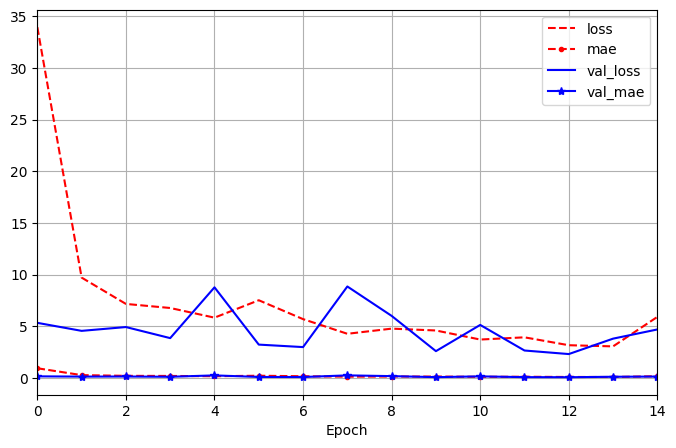

In [8]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 14], grid=True, xlabel='Epoch',
    style=['r--', 'r--.', 'b-', 'b-*', 'y-', 'y--.']
)

**Training Behavior**  
- **Rapid convergence:** Training loss and MAE fall to near zero by epoch 3, indicating the network quickly memorizes the training data.  
- **MAPE collapse:** Relative error (MAPE) also drops to almost 0 %, confirming near‐perfect fit on train.

**Validation Behavior**  
- **Initial drop:** Validation loss and MAE decrease from ~5 down to ~3 by epochs 2–4.  
- **Plateau & oscillations:** After epoch 4 they oscillate between ~3–6, with noticeable spikes at epochs 4 and 8—likely due to learning‐rate changes or batch noise.  
- **Generalization gap:** Training MAE→0 vs. validation MAE≈0.1 (and MAPE≈2–5 %) shows a non‐zero validation error despite perfect train fit.

In [11]:
# Save this models, we havent done any changes to the features based on the randomforest regressor, yet.

model.save('../models/cnn_prototype_01.keras')